# Кластеризация ЕГЭ (8.5 если сделаны все задачи)

Рядом лежат экселевские таблицы с координатами точек. В 3 и 4 задаче используется манхетеское расстояние. В остальных Евклидово.

* Постройте Распределение точек
* Кластеризуйте руками
* Постройте Распределение точек, отметьте принадлежность кластеров цветами
* Найдите среди в каждом кластере точку расстояние от которой до всех остальных минимально
* Выведите усреднение центров всех кластеров * 1000

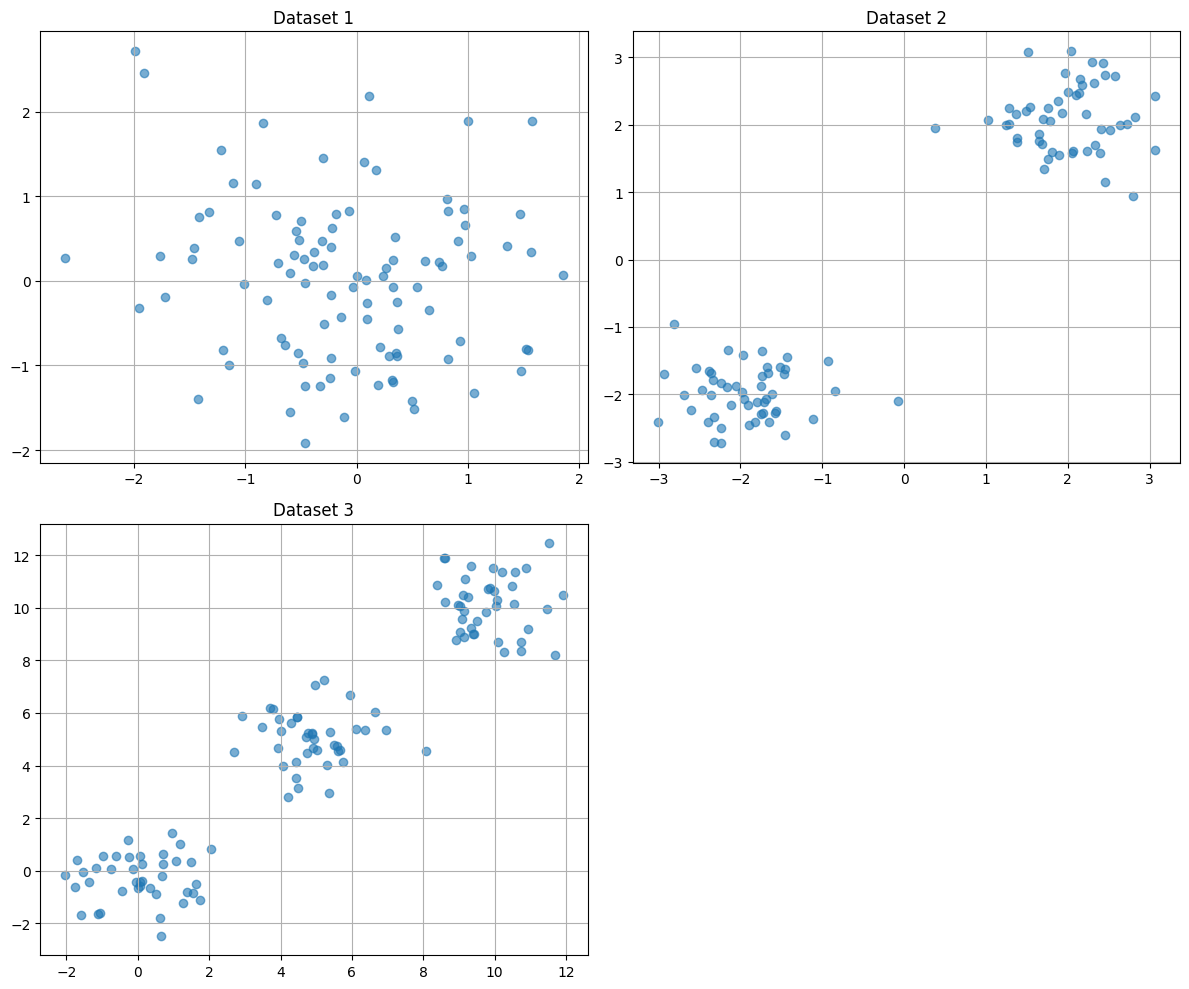

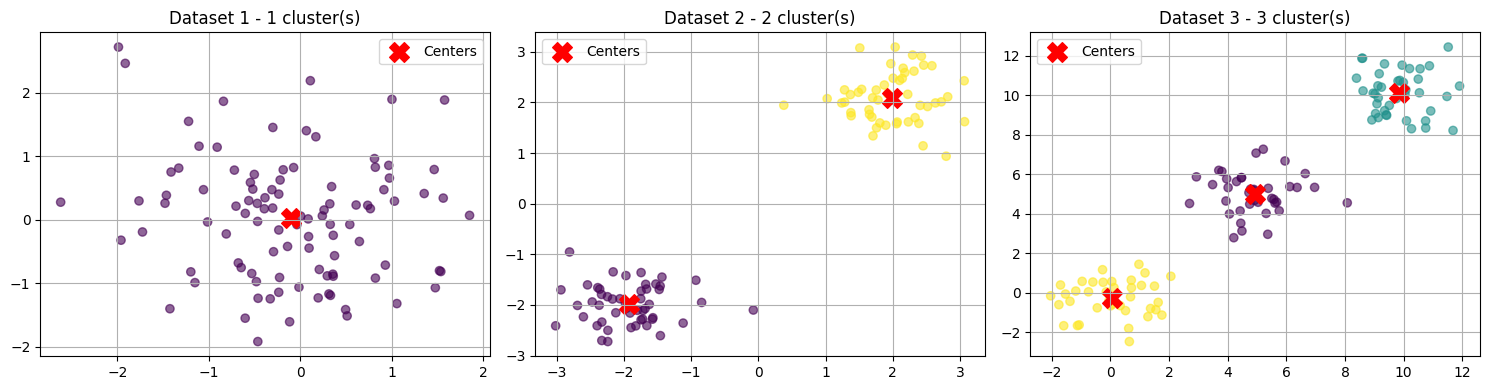

Dataset 1 - Central point: [-0.03582604 -0.07710171], Total distance: 115.10
Dataset 2, Cluster 0 - Central point: [-1.97721408 -1.96209772], Total distance: 28.61
Dataset 2, Cluster 1 - Central point: [1.92410745 2.17087799], Total distance: 32.96
Dataset 3, Cluster 0 - Central point: [4.9373209  5.01841838], Total distance: 49.86
Dataset 3, Cluster 1 - Central point: [9.76105195 9.8419921 ], Total distance: 51.64
Dataset 3, Cluster 2 - Central point: [ 0.11567463 -0.38455554], Total distance: 49.63

All cluster centers: [[-0.10384652  0.02230459]
 [-1.92451533 -1.98390932]
 [ 1.98941158  2.09074944]
 [ 4.92026771  5.02669398]
 [ 9.84223813 10.12097712]
 [ 0.05372856 -0.27120355]]
Average center: [2.46288069 2.50093538]
Average center * 1000: [2462.88068903 2500.935377  ]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)
data1 = pd.DataFrame({
    'x': np.random.normal(0, 1, 100),
    'y': np.random.normal(0, 1, 100)
})

data2 = pd.DataFrame({
    'x': np.concatenate([np.random.normal(-2, 0.5, 50), np.random.normal(2, 0.5, 50)]),
    'y': np.concatenate([np.random.normal(-2, 0.5, 50), np.random.normal(2, 0.5, 50)])
})

data3 = pd.DataFrame({
    'x': np.concatenate([np.random.normal(0, 1, 40), np.random.normal(5, 1, 40), np.random.normal(10, 1, 40)]),
    'y': np.concatenate([np.random.normal(0, 1, 40), np.random.normal(5, 1, 40), np.random.normal(10, 1, 40)])
})
def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
datasets = [data1, data2, data3]

for i, data in enumerate(datasets):
    ax = axes[i // 2, i % 2]
    ax.scatter(data['x'], data['y'], alpha=0.6)
    ax.set_title(f'Dataset {i+1}')
    ax.grid(True)

axes[1, 1].axis('off')
plt.tight_layout()
plt.show()
from sklearn.cluster import KMeans

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, data in enumerate(datasets):
    n_clusters = 2 if i == 1 else (3 if i == 2 else 1)

    if n_clusters > 1:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(data[['x', 'y']])
        centers = kmeans.cluster_centers_
    else:
        clusters = np.zeros(len(data))
        centers = [data[['x', 'y']].mean().values]

    ax = axes[i]
    scatter = ax.scatter(data['x'], data['y'], c=clusters, cmap='viridis', alpha=0.6)
    ax.scatter(np.array(centers)[:, 0], np.array(centers)[:, 1],
               c='red', marker='X', s=200, label='Centers')
    ax.set_title(f'Dataset {i+1} - {n_clusters} cluster(s)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()
def find_central_point(points, distance_func=euclidean_distance):
    """Находит точку с минимальной суммой расстояний до всех других точек"""
    points_array = points.values if hasattr(points, 'values') else points
    min_distance = float('inf')
    central_point_idx = -1

    for i in range(len(points_array)):
        total_distance = 0
        for j in range(len(points_array)):
            if i != j:
                total_distance += distance_func(points_array[i], points_array[j])

        if total_distance < min_distance:
            min_distance = total_distance
            central_point_idx = i

    return central_point_idx, min_distance

central_points = []

for i, data in enumerate(datasets):
    if i == 0:
        idx, dist = find_central_point(data[['x', 'y']])
        central_points.append(data.iloc[idx])
        print(f"Dataset {i+1} - Central point: {data.iloc[idx].values}, Total distance: {dist:.2f}")

    elif i == 1:
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(data[['x', 'y']])

        for cluster_id in range(2):
            cluster_points = data[clusters == cluster_id]
            idx, dist = find_central_point(cluster_points[['x', 'y']])
            central_points.append(cluster_points.iloc[idx])
            print(f"Dataset {i+1}, Cluster {cluster_id} - Central point: {cluster_points.iloc[idx].values}, Total distance: {dist:.2f}")

    else:
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(data[['x', 'y']])

        for cluster_id in range(3):
            cluster_points = data[clusters == cluster_id]
            idx, dist = find_central_point(cluster_points[['x', 'y']])
            central_points.append(cluster_points.iloc[idx])
            print(f"Dataset {i+1}, Cluster {cluster_id} - Central point: {cluster_points.iloc[idx].values}, Total distance: {dist:.2f}")

all_centers = []

for i, data in enumerate(datasets):
    if i == 0:
        center = data[['x', 'y']].mean().values
        all_centers.append(center)
    else:
        n_clusters = 2 if i == 1 else 3
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        kmeans.fit(data[['x', 'y']])
        all_centers.extend(kmeans.cluster_centers_)

all_centers_array = np.array(all_centers)
average_center = all_centers_array.mean(axis=0)
result = average_center * 1000

print(f"\nAll cluster centers: {all_centers_array}")
print(f"Average center: {average_center}")
print(f"Average center * 1000: {result}")

# Кластеризация (0.75 за каждый алгоритм на всех данных)

На предложенных распределениях данных проверьте предложенные алгоритмы. Постройте графики кластеризации для каждой пары алгоритм-данные, разные кластеры покрасьте разным цветом. Воспользуйтесь sklearn реализациями. Параметры кластеризации для разных алгоритмов подберите такие, чтобы алгоритмы можно было сравнивать (по возможности одинаковое количество кластеров и т.д.)

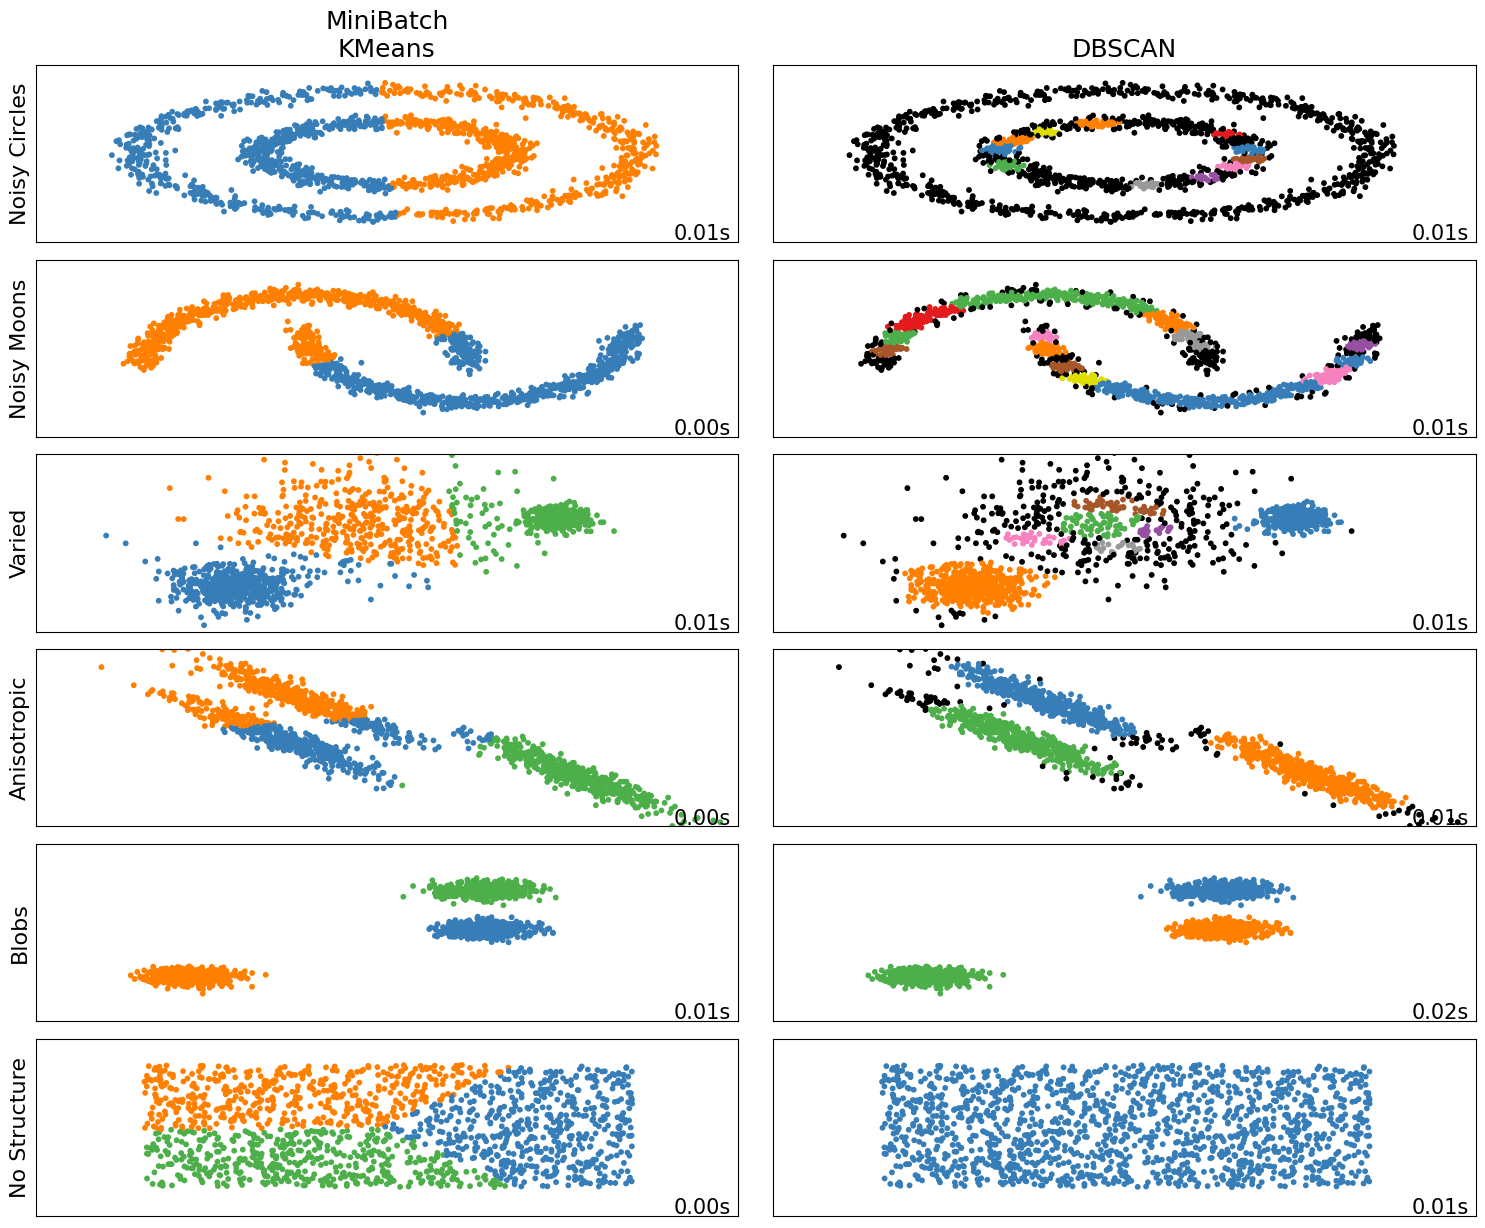

Silhouette Scores for each dataset and algorithm:

Noisy Circles:
------------------------------
MiniBatch
KMeans: 0.3515
DBSCAN: -0.3881

Noisy Moons:
------------------------------
MiniBatch
KMeans: 0.4994
DBSCAN: 0.1163

Varied:
------------------------------
MiniBatch
KMeans: 0.6259
DBSCAN: 0.4034

Anisotropic:
------------------------------
MiniBatch
KMeans: 0.5114
DBSCAN: 0.4533

Blobs:
------------------------------
MiniBatch
KMeans: 0.8104
DBSCAN: 0.8104

No Structure:
------------------------------
MiniBatch
KMeans: 0.3690
DBSCAN: Cannot compute (only 1 cluster)


In [2]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

warnings.filterwarnings("ignore")

np.random.seed(0)
n_samples = 1500

noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

plt.figure(figsize=(15, 12))
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.001, top=0.96, wspace=0.05, hspace=0.1)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 10,
    "n_clusters": 3,
    "min_samples": 20,
    "xi": 0.05,
    "min_cluster_size": 0.1,
}

datasets_list = [
    (noisy_circles, {"n_clusters": 2, "eps": 0.1}),
    (noisy_moons, {"n_clusters": 2, "eps": 0.1}),
    (varied, {"n_clusters": 3, "eps": 0.18}),
    (aniso, {"n_clusters": 3, "eps": 0.15}),
    (blobs, {"n_clusters": 3}),
    (no_structure, {"n_clusters": 3}),
]

clustering_algorithms = [
    ("MiniBatch\nKMeans", lambda params: cluster.MiniBatchKMeans(
        n_clusters=params["n_clusters"]
    )),
    ("DBSCAN", lambda params: cluster.DBSCAN(
        eps=params.get("eps", 0.3),
        min_samples=params.get("min_samples", default_base["min_samples"])
    )),
]

for i_dataset, (dataset, algo_params) in enumerate(datasets_list):

    params = default_base.copy()
    params.update(algo_params)
    X, y = dataset
    X = StandardScaler().fit_transform(X)

    for i_alg, (name, algorithm_constructor) in enumerate(clustering_algorithms):
        algorithm = algorithm_constructor(params)
        t0 = time.time()

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            algorithm.fit(X)

        t1 = time.time()

        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(datasets_list), len(clustering_algorithms), plot_num)

        if i_dataset == 0:
            plt.title(name, size=18)

        colors = np.array(list(islice(cycle([
            '#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628',
            '#984ea3', '#999999', '#e41a1c', '#dede00'
        ]), int(max(y_pred) + 1))))

        colors = np.append(colors, ["#000000"])

        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])

        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(0.99, 0.01, f'{(t1 - t0):.2f}s',
                transform=plt.gca().transAxes, size=15,
                horizontalalignment='right')

        if i_alg == 0:
            dataset_names = [
                "Noisy Circles", "Noisy Moons", "Varied",
                "Anisotropic", "Blobs", "No Structure"
            ]
            plt.ylabel(dataset_names[i_dataset], size=16)

        plot_num += 1

plt.show()

from sklearn.metrics import silhouette_score

print("Silhouette Scores for each dataset and algorithm:")
print("=" * 60)

for i_dataset, (dataset, algo_params) in enumerate(datasets_list):
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset
    X = StandardScaler().fit_transform(X)

    dataset_names = [
        "Noisy Circles", "Noisy Moons", "Varied",
        "Anisotropic", "Blobs", "No Structure"
    ]

    print(f"\n{dataset_names[i_dataset]}:")
    print("-" * 30)

    for name, algorithm_constructor in clustering_algorithms:
        algorithm = algorithm_constructor(params)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            algorithm.fit(X)

        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        if len(np.unique(y_pred)) > 1:
            score = silhouette_score(X, y_pred)
            print(f"{name}: {score:.4f}")
        else:
            print(f"{name}: Cannot compute (only 1 cluster)")